In [13]:
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from xgboost import XGBClassifier

df = pd.read_csv("../data/Student Depression Dataset.csv")
df = df.rename(columns={
    "Have you ever had suicidal thoughts ?": "Suicidal Thoughts"
})
df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Suicidal Thoughts,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [14]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id                                27901 non-null  int64  
 1   Gender                            27901 non-null  object 
 2   Age                               27901 non-null  float64
 3   City                              27901 non-null  object 
 4   Profession                        27901 non-null  object 
 5   Academic Pressure                 27901 non-null  float64
 6   Work Pressure                     27901 non-null  float64
 7   CGPA                              27901 non-null  float64
 8   Study Satisfaction                27901 non-null  float64
 9   Job Satisfaction                  27901 non-null  float64
 10  Sleep Duration                    27901 non-null  object 
 11  Dietary Habits                    27901 non-null  object 
 12  Degr

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
count,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27898.000000,27901.000000
mean,70442.149421,25.822300,3.141214,0.000430,7.656104,2.943837,0.000681,7.156984,3.139867,0.585499
std,40641.175216,4.905687,1.381465,0.043992,1.470707,1.361148,0.044394,3.707642,1.437347,0.492645
min,2.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,35039.000000,21.000000,2.000000,0.000000,6.290000,2.000000,0.000000,4.000000,2.000000,0.000000
50%,70684.000000,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,3.000000,1.000000
75%,105818.000000,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,4.000000,1.000000
max,140699.000000,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,5.000000,1.000000


#### Kollar saknade värden:

In [15]:
df.isna().sum()

id                                  0
Gender                              0
Age                                 0
City                                0
Profession                          0
Academic Pressure                   0
Work Pressure                       0
CGPA                                0
Study Satisfaction                  0
Job Satisfaction                    0
Sleep Duration                      0
Dietary Habits                      0
Degree                              0
Suicidal Thoughts                   0
Work/Study Hours                    0
Financial Stress                    3
Family History of Mental Illness    0
Depression                          0
dtype: int64

#### Kollar kategoriska variabler:

In [16]:
df.columns

Index(['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree', 'Suicidal Thoughts',
       'Work/Study Hours', 'Financial Stress',
       'Family History of Mental Illness', 'Depression'],
      dtype='object')

In [17]:
df["Depression Label"] = df["Depression"].map({
    0: "No Depression",
    1: "Depression"
})

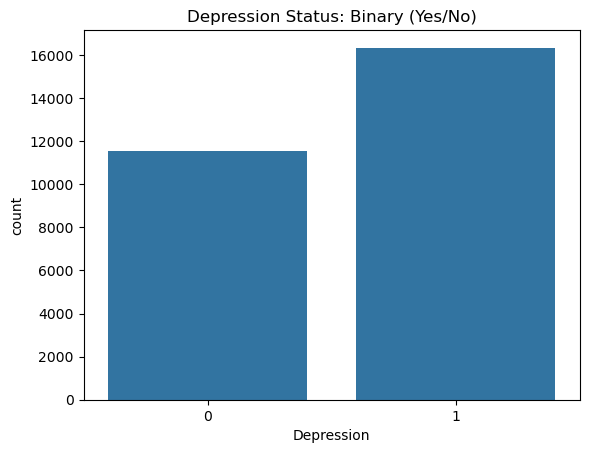

Depression
1    16336
0    11565
Name: count, dtype: int64


In [18]:
counts = df["Depression"].value_counts()

sns.countplot(data=df, x="Depression")
plt.title("Depression Status: Binary (Yes/No)")
plt.show()
print(counts)

---
#### Jämför depression mot viktiga variabler:

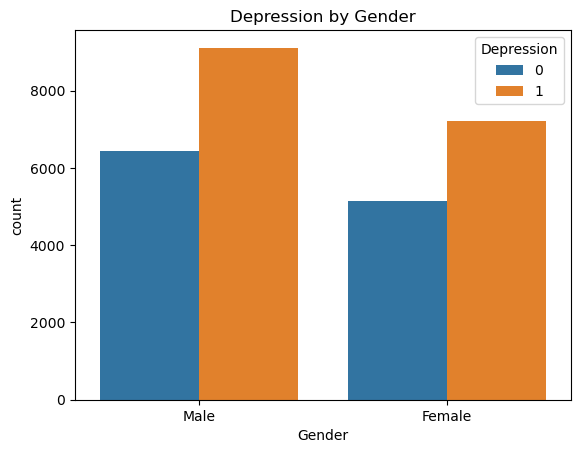

In [153]:
sns.countplot(data=df, x="Gender", hue="Depression")
plt.title("Depression by Gender")
plt.show()

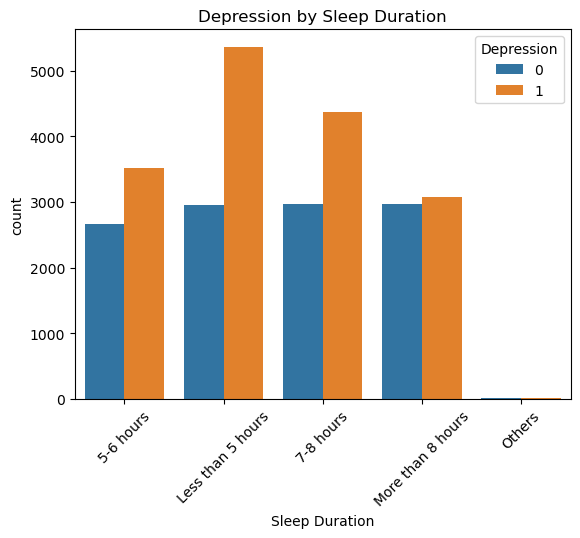

In [154]:
sns.countplot(data=df, x="Sleep Duration", hue="Depression")
plt.title("Depression by Sleep Duration")
plt.xticks(rotation=45)
plt.show()

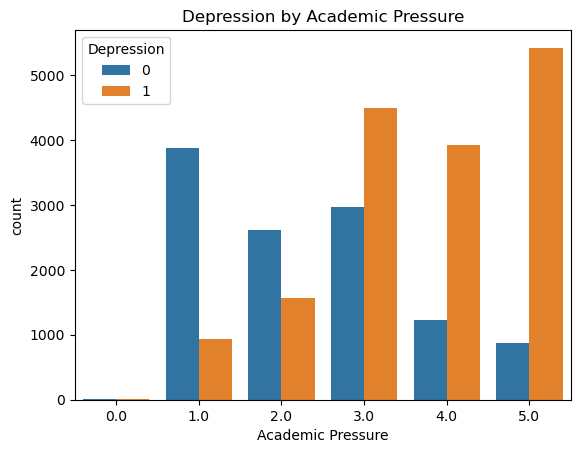

In [155]:
sns.countplot(data=df, x="Academic Pressure", hue="Depression")
plt.title("Depression by Academic Pressure")
plt.show()

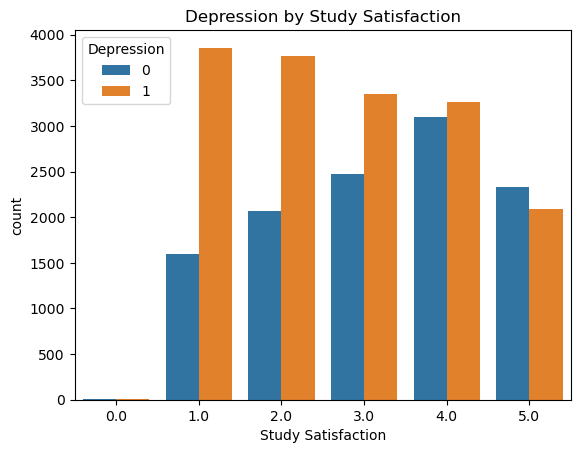

In [156]:
sns.countplot(data=df, x="Study Satisfaction", hue="Depression")
plt.title("Depression by Study Satisfaction")
plt.show()

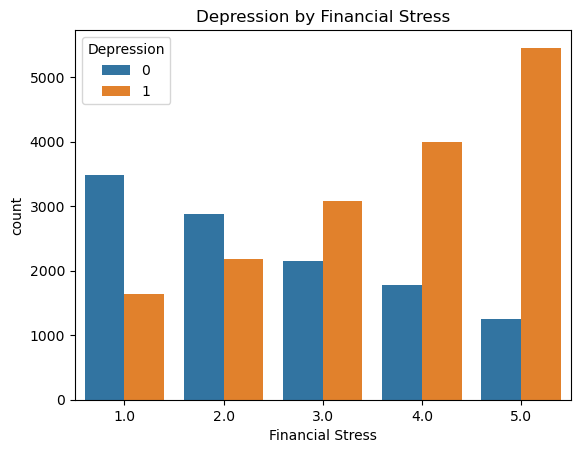

In [157]:
sns.countplot(data=df, x="Financial Stress", hue="Depression")
plt.title("Depression by Financial Stress")
plt.show()

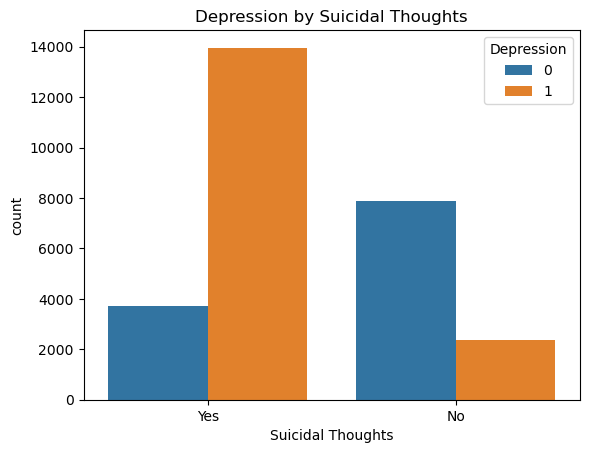

In [158]:
sns.countplot(data=df, x="Suicidal Thoughts", hue="Depression")
plt.title("Depression by Suicidal Thoughts")
plt.show()

---
# Datapreprocessing

### Identifiera kategoriska kolumner:

In [159]:
df.select_dtypes(include="object").columns

Index(['Gender', 'City', 'Profession', 'Sleep Duration', 'Dietary Habits',
       'Degree', 'Suicidal Thoughts', 'Family History of Mental Illness'],
      dtype='object')

### Tar bort kolumner:
För att minska komplexitet, risk för overfitting, sämre modellprestation och att skapa ett för tungt projekt utan mycket värde, så tar vi bort dessa kolumner.

In [19]:
# Kopia för modellering
df_model = df.copy()

# Ta bort kolumner som inte ska användas i modellen
df_model = df_model.drop(columns=[
    "id",
    "City",
    "Profession",
    "Depression Label"
], errors="ignore")

### Encoding - omvandla kategorier till siffror:

In [36]:
# Target
y = df_model["Depression"]

# Feature
X = df_model.drop("Depression", axis=1)

# One-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Viktigt: gör alla kolumner numeriska float
X = X.astype("float32")
y = y.astype("float32")

X = X.fillna(X.median())

X.columns

Index(['Age', 'Academic Pressure', 'Work Pressure', 'CGPA',
       'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours',
       'Financial Stress', 'Gender_Male', 'Sleep Duration_7-8 hours',
       'Sleep Duration_Less than 5 hours', 'Sleep Duration_More than 8 hours',
       'Sleep Duration_Others', 'Dietary Habits_Moderate',
       'Dietary Habits_Others', 'Dietary Habits_Unhealthy', 'Degree_B.Com',
       'Degree_B.Ed', 'Degree_B.Pharm', 'Degree_B.Tech', 'Degree_BA',
       'Degree_BBA', 'Degree_BCA', 'Degree_BE', 'Degree_BHM', 'Degree_BSc',
       'Degree_Class 12', 'Degree_LLB', 'Degree_LLM', 'Degree_M.Com',
       'Degree_M.Ed', 'Degree_M.Pharm', 'Degree_M.Tech', 'Degree_MA',
       'Degree_MBA', 'Degree_MBBS', 'Degree_MCA', 'Degree_MD', 'Degree_ME',
       'Degree_MHM', 'Degree_MSc', 'Degree_Others', 'Degree_PhD',
       'Suicidal Thoughts_Yes', 'Family History of Mental Illness_Yes'],
      dtype='object')

In [37]:
# Kontrollera vilka kolumner som har NaN
X.isna().sum()[X.isna().sum() > 0]

Series([], dtype: int64)

In [38]:
# Fyll numeriska NaN med median
X = X.fillna(X.median())

### Train/test split:

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Scaling (viktigt för ANN):

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train).astype("float32")
X_test_scaled = scaler.transform(X_test).astype("float32")

---
### Import och skapa modell:

In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(16, activation="relu"),
    Dense(8, activation="relu"),
    Dense(1, activation="sigmoid")
])

#### Vad lagren betyder:
**Första(16)**  
- 16 neuroner
- försöker hitta mönster i datan
- relu är standard för hidden layers

**Andra(8)**  
- ytterligare mönsterigenkänning
- lite mindre lager

**Tredje(1)**  
Eftersom vi gör:
- 0 = No Depression  
- 1 = Depression

Sigmoid ger ett värde mellan:  
0 och 1 (alltså sannolikhet)

### Compile modellen:

In [42]:
from tensorflow.keras.optimizers import Adam
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

### Träna modellen:

In [43]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
558/558 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7940 - loss: 0.4537 - val_accuracy: 0.8360 - val_loss: 0.3730
Epoch 2/20
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8454 - loss: 0.3580 - val_accuracy: 0.8416 - val_loss: 0.3631
Epoch 3/20
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8477 - loss: 0.3504 - val_accuracy: 0.8407 - val_loss: 0.3605
Epoch 4/20
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8498 - loss: 0.3471 - val_accuracy: 0.8385 - val_loss: 0.3605
Epoch 5/20
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8504 - loss: 0.3452 - val_accuracy: 0.8394 - val_loss: 0.3598
Epoch 6/20
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8518 - loss: 0.3437 - val_accuracy: 0.8409 - val_loss: 0.3611
Epoch 7/20
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8522 - loss: 0.3423 - val_accuracy: 0.8374 - val_loss: 0.3590
Epoch 8/20
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8527 - loss: 0.3411 - val_accuracy: 0.

In [44]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts(normalize=True))

print("\nMissing values in X:")
print(X.isna().sum().sum())

print("\nColumns containing Depression:")
print([col for col in X.columns if "Depression" in col])

X shape: (27901, 45)
y shape: (27901,)

Target distribution:
Depression
1.0    0.585499
0.0    0.414501
Name: proportion, dtype: float64

Missing values in X:
0

Columns containing Depression:
[]


In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Accuracy: 0.8453682135817954
[[1841  472]
 [ 391 2877]]
              precision    recall  f1-score   support

         0.0       0.82      0.80      0.81      2313
         1.0       0.86      0.88      0.87      3268

    accuracy                           0.85      5581
   macro avg       0.84      0.84      0.84      5581
weighted avg       0.84      0.85      0.84      5581



#### Tolkning:
```
Faktiskt                      Förutspått
No Depression → korrekt	      1841      
No Depression → fel	      472       
Depression → missad	      391       
Depression → korrekt	      2877      
```

**Metric**        **Resultat**
```
Accuracy               | 84.5%    |
Precision (Depression) | 86%      |
Recall (Depression)    | 88%      |
F1-score               | 87%      |
```

**Recall = 88%**

Modellen hittar:  
88% av personer med depression.

---

## Visualisera training history

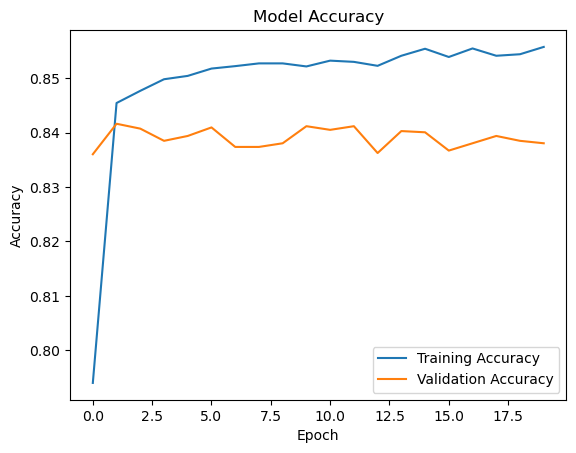

In [51]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

#### Accuracy-grafen:
- training accuracy går upp stabilt
- validation accuracy ligger ganska stabilt runt 0.84
- kurvorna ligger nära varandra  

Det betyder:
- modellen generaliserar ganska bra.

Alltså:  
- den memoriserar inte bara träningsdatan
- den fungerar även på ny data

**Viktig observation**

Mot slutet börjar training accuracy fortsätta uppåt medan validation accuracy planar ut.

Det är början till:
- overfitting

Men det är ganska mild overfitting, inte katastrofalt.

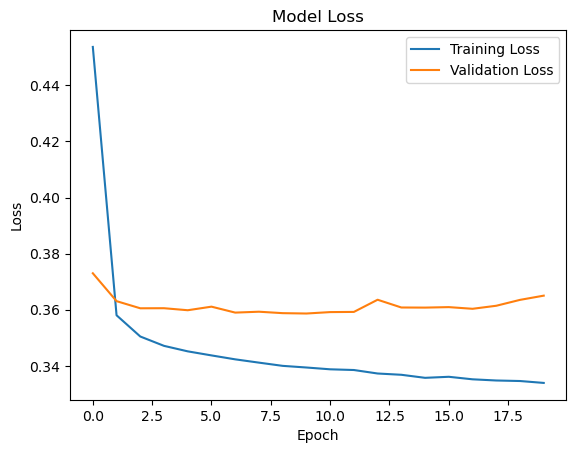

In [52]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

#### Loss-grafen
Här syns det ännu tydligare:
- training loss fortsätter minska
- validation loss planar ut och börjar öka lite

Det betyder:
- modellen fortsätter lära sig träningsdatan, men förbättras inte längre på okänd data.

## Viktig slutsats

Detta betyder sannolikt:
- 10–12 epochs hade varit optimalt

Vi tränade egentligen lite för länge.

Ger oss möjlighet att prata om:
- overfitting
- model optimization
- balancing training vs validation performance
---

## Early Stopping

In [53]:
from tensorflow.keras.callbacks import EarlyStopping

#### Skapa callback:

In [54]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

#### Vad det betyder:
| Parameter                   | Förklaring                       |
| --------------------------- | -------------------------------- |
| `monitor="val_loss"`        | övervakar validation loss        |
| `patience=3`                | väntar 3 epochs utan förbättring |
| `restore_best_weights=True` | återgår till bästa modellen      |


#### Träna modellen igen:

In [55]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/20
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8558 - loss: 0.3337 - val_accuracy: 0.8367 - val_loss: 0.3623
Epoch 2/20
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8560 - loss: 0.3330 - val_accuracy: 0.8367 - val_loss: 0.3637
Epoch 3/20
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8557 - loss: 0.3323 - val_accuracy: 0.8358 - val_loss: 0.3645
Epoch 4/20
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8547 - loss: 0.3328 - val_accuracy: 0.8396 - val_loss: 0.3619
Epoch 5/20
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8563 - loss: 0.3321 - val_accuracy: 0.8376 - val_loss: 0.3637
Epoch 6/20
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8568 - loss: 0.3315 - val_accuracy: 0.8374 - val_loss: 0.3655
Epoch 7/20
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8561 - loss: 0.3314 - val_accuracy: 0.8362 - val_loss: 0.3663


#### Förklaring:
För att reducera overfitting implementerades Early Stopping för att stoppa träningen när validation performance slutade att förbättras.
- optimering
- förbättring
- utvärdering

#### Resultat:
- träningen stoppas tidigare
- modellen generaliserar bättre
- mindre risk för overfitting
---

#### Slutgiltig evaluation:

In [56]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 939us/step
Accuracy: 0.8394552947500448
[[1825  488]
 [ 408 2860]]
              precision    recall  f1-score   support

         0.0       0.82      0.79      0.80      2313
         1.0       0.85      0.88      0.86      3268

    accuracy                           0.84      5581
   macro avg       0.84      0.83      0.83      5581
weighted avg       0.84      0.84      0.84      5581



| Metric                 | Result |
| ---------------------- | ------ |
| Accuracy               | 84%    |
| Precision (Depression) | 85%    |
| Recall (Depression)    | 88%    |
| F1-score               | 86%    |


#### Slutgiltig confusion matrix heatmap:

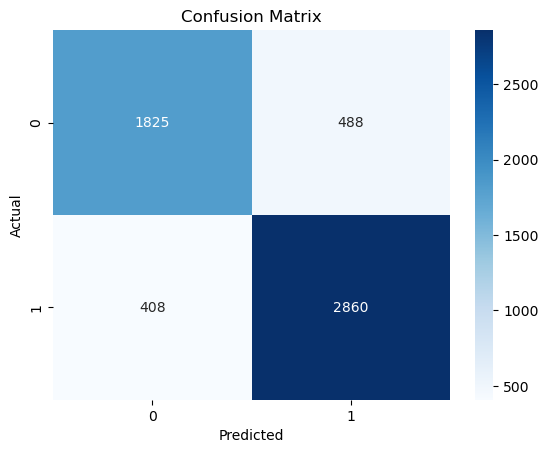

In [57]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

| Actual | Predicted                         |
| ------ | --------------------------------- |
| 1825   | Correctly predicted No Depression |
| 2860   | Correctly predicted Depression    |
| 488    | False positives                   |
| 408    | False negatives                   |


#### Viktigaste observationen
Modellen är bättre på att identifiera:
- Depression = 1

än:
- Depression = 0

Det syns i:
- Recall = 88%

.. för depression-klassen.

#### Varför detta är bra i vårt case
I mental health prediction är det ofta viktigare att:
- hitta personer i riskzonen
- minimera missade depression-fall

.. än att modellen är “perfekt balanserad”.

#### Heatmapen
Heatmapen visar tydligt att:
- majoriteten av predictionerna är korrekta
- modellen inte längre fastnar i majoritetsklassen
- ANN-modellen har lärt sig riktiga mönster i datan

Det här är en mycket bättre confusion matrix än vår första version där modellen bara gissade:
- 1

.. på allt.

---
## Slutsats
Projektets mål var att undersöka om en Artificial Neural Network-modell (ANN) kunde användas för att förutse risk för depression hos studenter baserat på faktorer som akademisk press, sömnvanor, livsstil och psykisk hälsa.

Efter datarengöring, preprocessing och träning av modellen uppnådde ANN-modellen en accuracy på cirka 84%. Modellen visade särskilt stark förmåga att identifiera studenter med depression, med en recall på 88%.

Under projektets gång upptäcktes att saknade värden i datasetet påverkade modellens prestanda kraftigt. Efter hantering av missing values förbättrades resultaten avsevärt, vilket visar hur viktig datarengöring är inom machine learning och deep learning.

Resultaten visar att deep learning kan användas för att identifiera mönster kopplade till psykisk ohälsa hos studenter och potentiellt fungera som ett stödverktyg inom studenthälsa och digitala vårdtjänster.

Trots goda resultat finns förbättringsmöjligheter, exempelvis:
- fler optimeringar av modellen
- test av fler lager och regularisering
- större och mer varierad data
- jämförelse med andra modeller

---
## Accuracy-graf - jämför flera metrics samtidigt:

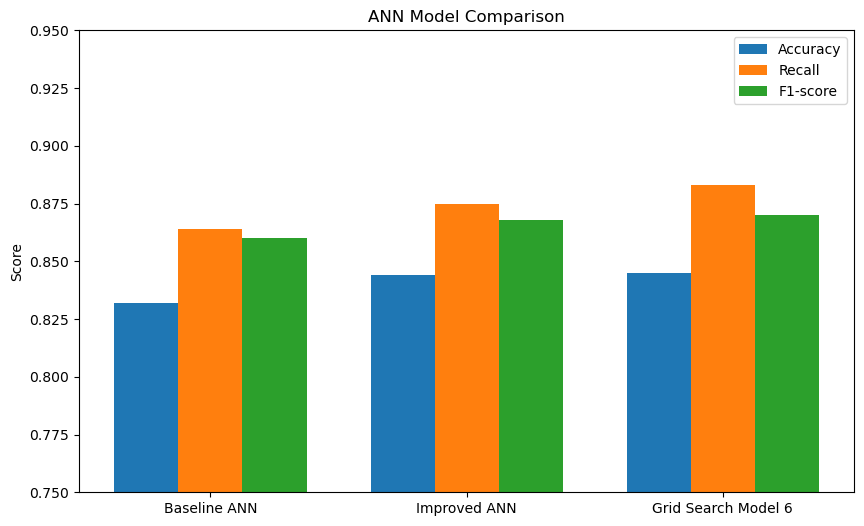

In [59]:
models = [
    "Baseline ANN",
    "Improved ANN",
    "Grid Search Model 6"
]

accuracy = [0.832, 0.844, 0.845]
recall = [0.864, 0.875, 0.883]
f1 = [0.860, 0.868, 0.870]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10,6))

plt.bar(x - width, accuracy, width, label="Accuracy")
plt.bar(x, recall, width, label="Recall")
plt.bar(x + width, f1, width, label="F1-score")

plt.xticks(x, models)

plt.ylabel("Score")
plt.title("ANN Model Comparison")

plt.ylim(0.75, 0.95)

plt.legend()

plt.show()